In [1]:
import pandas as pd 

from matplotlib import pyplot as plt

In [2]:
def load_data(dataset, task_id, layer, basis_name, relevance_from="grad"):

    return pd.read_csv(f"./artifacts/experiment-basis-comparisons/{dataset}/task-{task_id}/{layer}/relevance-{relevance_from}/{basis_name}.csv")

load_data(
    dataset="celeba-n8r0q2vb",
    task_id=0,
    layer="layer1",
    basis_name="PRCARecon",
)

,task_id,layer,use_lrp,output_quantity,k,basis_name,val_auroc
0,0,layer1,False,LogOddWinningClass,1,PRCARecon,0.666341
1,0,layer1,False,LogOddWinningClass,2,PRCARecon,0.617877
2,0,layer1,False,LogOddWinningClass,3,PRCARecon,0.790922
3,0,layer1,False,LogOddWinningClass,4,PRCARecon,0.894553
4,0,layer1,False,LogOddWinningClass,5,PRCARecon,0.927514
5,0,layer1,False,LogOddWinningClass,6,PRCARecon,0.948045
6,0,layer1,False,LogOddWinningClass,7,PRCARecon,0.949721
7,0,layer1,False,LogOddWinningClass,8,PRCARecon,0.950698
8,0,layer1,False,LogOddWinningClass,9,PRCARecon,0.952793
9,0,layer1,False,LogOddWinningClass,10,PRCARecon,0.955307


# Results: CelebA

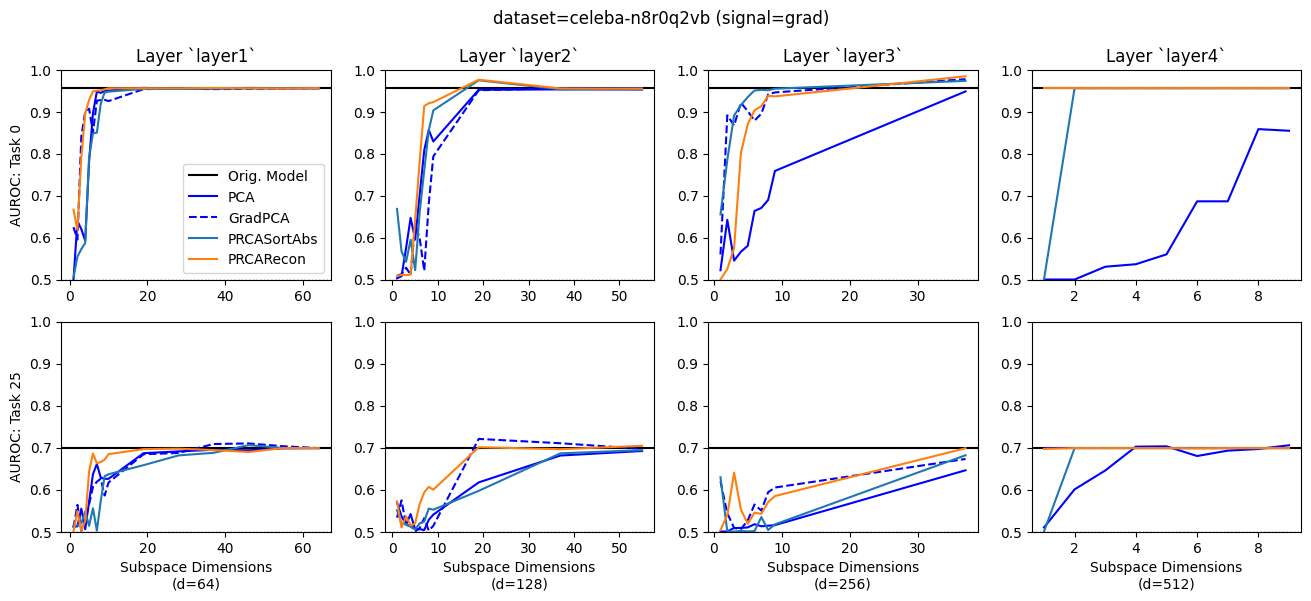

In [3]:
def viz(
    dataset="celeba-n8r0q2vb",
    arr_basis_names=[
        "PCA",
        "PRCASortAbs",
    ],
    arr_task_ids=[0, 1],
    arr_layers=["max1", "max2", "act3"],
    mapping_ls_color_marker= dict(
        PCA=("--", "blue", None),
        PCALookAhead=("-", "blue", None)
    ),
    perf_col="acc_test"
):
    nrows = len(arr_task_ids)
    ncols = len(arr_layers)

    max_k = 64

    relevance_from = "grad"

    def _ls_color_marker(basis_name):
        
        return mapping_ls_color_marker.get(f"{basis_name}", ("-", None, None))
        

    def _label(basis_name, relevance_from):
        if "PCA" in basis_name:
            return basis_name
        else:
            return f"{basis_name}"
    

    col_name = {
        "acc_test": "Accuracy",
        "val_auroc": "AUROC",
    }[perf_col]
    
    plt.figure(figsize=(4*ncols, 3*nrows))
    plt.suptitle(f"dataset={dataset} (signal={relevance_from})")
    for lix, layer in enumerate(arr_layers):
        for tix, task_id in enumerate(arr_task_ids):
        
            plt.subplot(nrows, ncols,  tix * ncols + lix + 1)

            if "auroc" in perf_col :
                plt.ylim([0.5, 1])
                plt.axhline(0.5, ls=":", color="black", lw=1)
            else:
                plt.ylim([0, 1])
                plt.axhline(1, ls=":", color="black", lw=1)
            for bix, basis_name in enumerate(arr_basis_names):
                    
                df = load_data(
                    dataset=dataset,
                    task_id=task_id,
                    layer=layer,
                    basis_name=basis_name,
                )
                if bix == 0:
                    __df = load_data(
                        dataset=dataset,
                        task_id=task_id,
                        layer=layer,
                        basis_name="PCA",
                    )
                    d = __df.k.values[-1]
                    
                    plt.axhline(__df[perf_col].values[-1], ls="-", color="k", label="Orig. Model")
                selected = df.k <= max_k

                ls, color, marker = _ls_color_marker(basis_name)
                plt.plot(
                    df.k[selected],
                    df[perf_col][selected],
                    label=_label(basis_name, relevance_from),
                    ls=ls,
                    color=color,
                    marker=marker
                )

                            
            if tix == 0:
                plt.title(f"Layer `{layer}`")

            if lix == 0:
                plt.ylabel(f"{col_name}: Task {task_id}")

            if tix == nrows - 1:
                plt.xlabel(f"Subspace Dimensions\n(d={d})")
                
            if lix == 0 and tix == 0:
                plt.legend()

 
        # PCA_lrp=("--", "blue", None),
        # PCALookAhead_lrp=("-", "blue", "*"),
        # PRCASortAbs_lrp=("--", "red", None),
        # PRCAReconGreedy_lrp=("-", "red", None),
        # PRCARecon_lrp=("-", "red", "*"),
    
viz(
    arr_basis_names=[
        "PCA",
        "GradPCA",
        "PRCASortAbs",
        "PRCARecon",
    ],
    perf_col="val_auroc",
    arr_layers=["layer1", "layer2", "layer3", "layer4"],
    arr_task_ids=[0, 25],
    mapping_ls_color_marker=dict(
        PCA=("-", "blue", None),
        GradPCA=("--", "blue", None)
    )
)

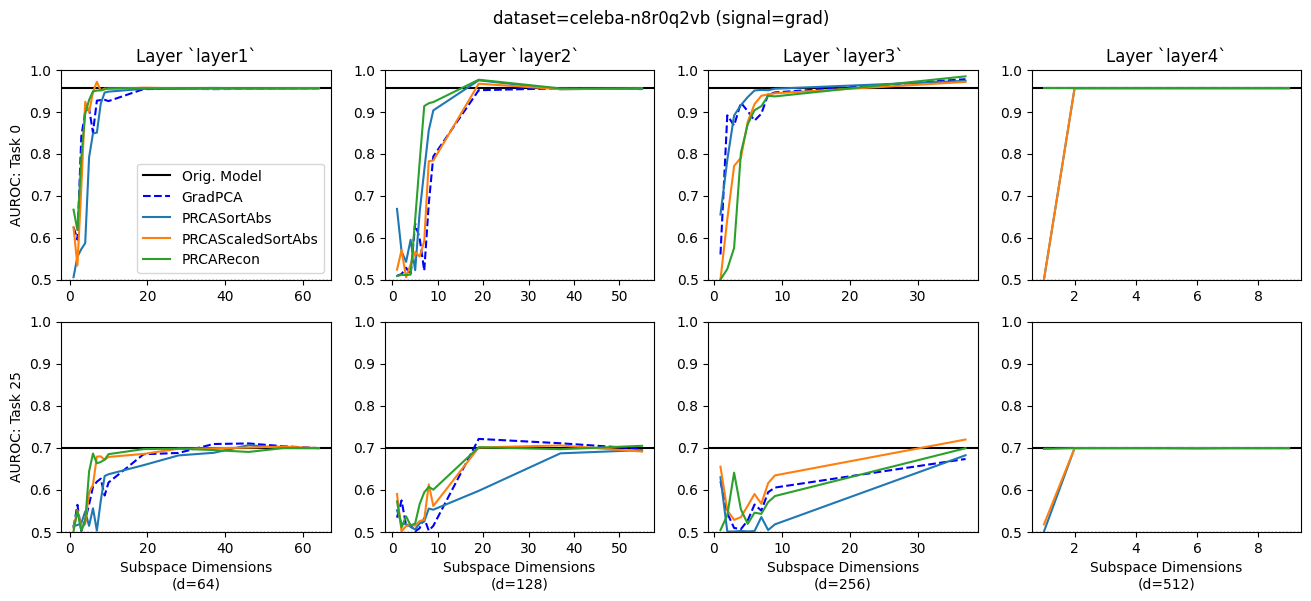

In [4]:
viz(
    arr_basis_names=[
        "GradPCA",
        "PRCASortAbs",
        # "PRCAScaled",
        "PRCAScaledSortAbs",
        # "PRCAScaledSubtractMedianSortAbs",    
        "PRCARecon"
    ],
    perf_col="val_auroc",
    arr_layers=["layer1", "layer2", "layer3", "layer4"],
    arr_task_ids=[0, 25],
    mapping_ls_color_marker=dict(
        GradPCA=("--", "blue", None)
    )
)

# MultiNIST

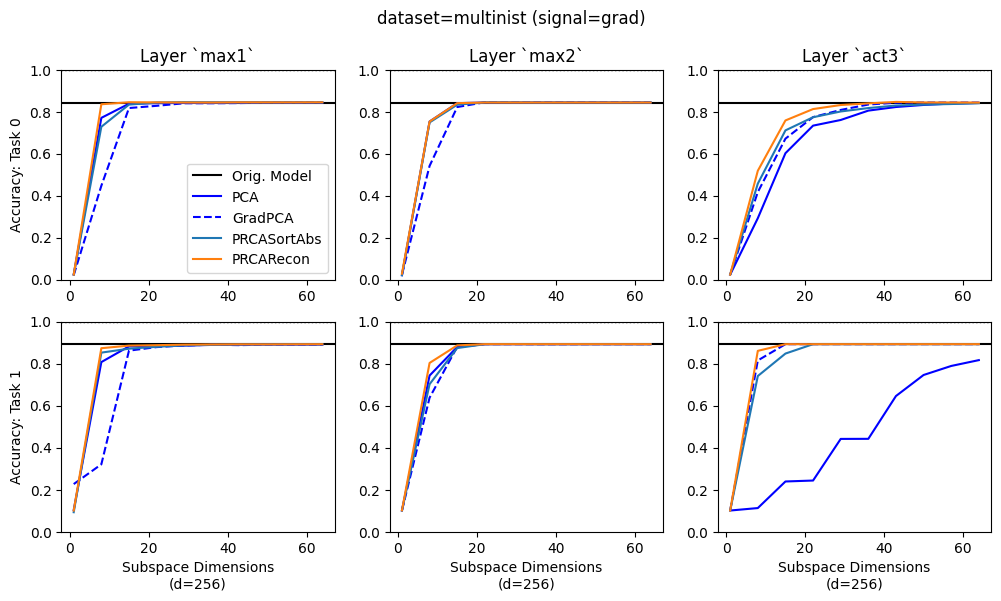

In [5]:
    
viz(
    dataset="multinist",
    arr_basis_names=[
        "PCA",
        "GradPCA",
        "PRCASortAbs",
        "PRCARecon",
    ],
    arr_layers=["max1", "max2", "act3"],
    arr_task_ids=[0, 1],
    mapping_ls_color_marker=dict(
        PCA=("-", "blue", None),
        GradPCA=("--", "blue", None)
    )
)

# MultiNIST Jacobian

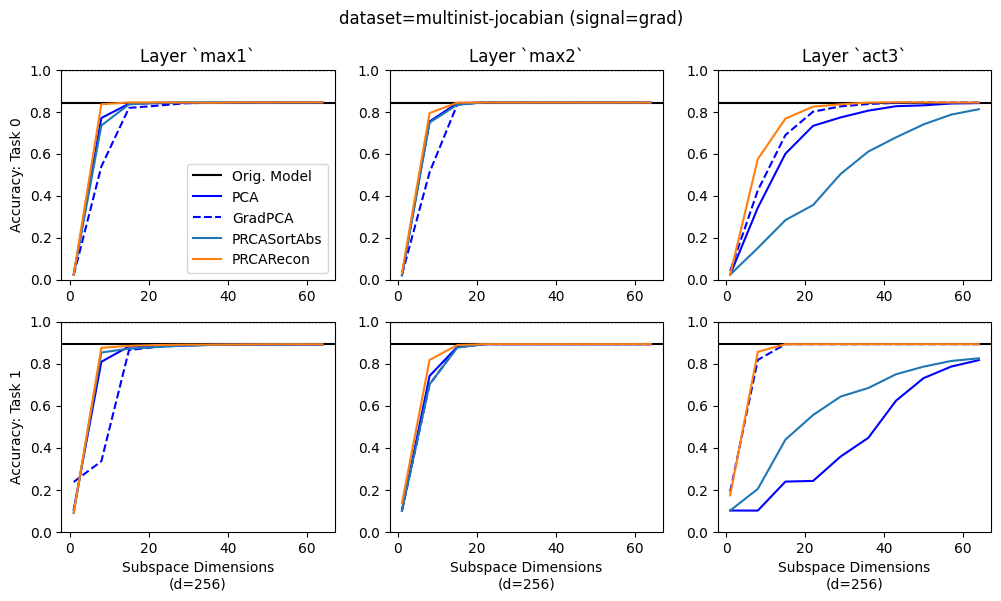

In [6]:
    
viz(
    dataset="multinist-jocabian",
    arr_basis_names=[
        "PCA",
        "GradPCA",
        "PRCASortAbs",
        "PRCARecon",
    ],
    arr_layers=["max1", "max2", "act3"],
    arr_task_ids=[0, 1],
    mapping_ls_color_marker=dict(
        PCA=("-", "blue", None),
        GradPCA=("--", "blue", None)
    )
)

## Comparison between using grad of winning and jacobian

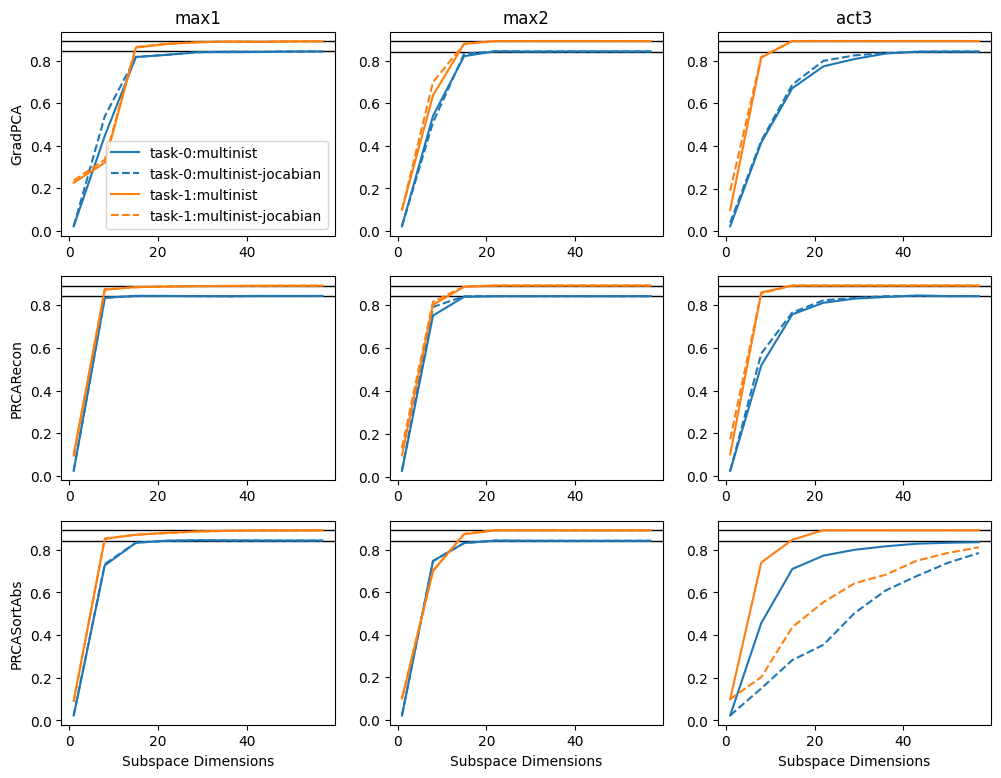

In [7]:
def viz_comparision(

    arr_basis_names=["GradPCA", "PRCARecon", "PRCASortAbs"]
):

    arr_layers = ["max1", "max2", "act3"]
    nrows = len(arr_basis_names)
    ncols = len(arr_layers)
    plt.figure(figsize=(4*nrows, 3*ncols))

    for bix, basis_name in enumerate(arr_basis_names):
        
        for lix, layer in enumerate(arr_layers):
            plt.subplot(nrows, ncols, bix*ncols + lix + 1)
        
            for task_id in [0, 1]:
                for dix, dataset in enumerate(["multinist", "multinist-jocabian"]):
                        
                    df = load_data(
                        dataset=dataset,
                        task_id=task_id,
                        layer=layer,
                        basis_name=basis_name,
                    )

                    if dix == 0:
                        plt.axhline(
                            df["acc_test"].values[-1], 
                            lw=1, 
                            color="k", 
                            ls="-"
                        )
                    selected = df.k <= 60
                    plt.plot(
                        df.k[selected],
                        df["acc_test"][selected],
                        color=plt.gca().lines[-1].get_color() if dix == 1 else None,
                        ls="--" if dix == 1 else "-",
                        label=f"task-{task_id}:{dataset}",
                    )

            if bix == 0:
                plt.title(layer)
            if lix == 0:
                plt.ylabel(basis_name)

            if lix == bix == 0:
                plt.legend()
            if bix == nrows - 1:
                plt.xlabel("Subspace Dimensions")
viz_comparision()